In [ ]:
# ============================================================
# SUPPLEMENTAL NOTEBOOK 1 — Model re-runs (SGD vs deterministic solvers, XGBoost, Huber)
#
# NOTE ON DATA: This notebook re-runs a targeted comparison on the BASE experimental
# datasets (raw features + targets per task). Those base datasets are the source data for
# the companion FAIR2 data-resource article and are NOT duplicated in this repository to
# avoid maintaining multiple copies of the same data. The code and all resulting outputs
# are provided here; the outputs are saved and visible without re-running. To regenerate
# the results, obtain the base datasets (available via the companion article) and set
# BASE_DIR below to their location.
# ============================================================
import os, time, math
import pandas as pd, numpy as np, scipy as sp
from pathlib import Path

# --- base-data location (genericized; set to your local base-data folder to re-run) ---
BASE_DIR = Path(r"<PATH_TO_BASE_DATASETS>")   # e.g. the "Base data and ML problems" folder
# REPO root (for saving supplementary outputs) — resolves relative to this notebook
here = Path.cwd()
for p in [here, *here.parents]:
    if (p / "utils.py").exists() or (p / ".git").exists():
        REPO = p; break
else:
    REPO = here
(SUPP := REPO / "supplementary").mkdir(exist_ok=True)

if BASE_DIR.exists():
    os.chdir(BASE_DIR)
    print("base data found — notebook can re-run. cwd:", BASE_DIR)
else:
    print("BASE_DIR not set/found — this notebook's SAVED OUTPUTS below are the record;")
    print("set BASE_DIR to the base datasets (companion article) to regenerate.")

In [3]:
# Automatically determine whether the problem is a classification or regression task and assign it to a variable (which is used to select algorithms, scoring metrics, and CV schemes)
def determine_ML_task(y):
  if y.unique().shape[0] <= 5:
    problem_type='classification'
  else:
    problem_type='regression'
  return problem_type

In [4]:
# Imports for models 
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import SGDClassifier, SGDRegressor
from sklearn.naive_bayes import CategoricalNB
from sklearn.gaussian_process import GaussianProcessClassifier, GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, DotProduct, RationalQuadratic, Matern, ConstantKernel, WhiteKernel
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.svm import SVC, SVR
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPClassifier, MLPRegressor

# Dict to hold the models 
algo_dict = {}; grid_dict = {}

random_state=0; n_jobs=None

In [5]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, average_precision_score, roc_auc_score
from sklearn.metrics import mean_absolute_error, median_absolute_error, mean_absolute_percentage_error, r2_score, explained_variance_score, max_error
#from sklearn.model_selection import StratifiedGroupKFold
#from sklearn.model_selection import GroupKFold

# Imports for grid-searching 
from sklearn.model_selection import GridSearchCV

# Imports for modeling pipeline 
from sklearn.pipeline import Pipeline

In [6]:
# Function to extract relevant information from the exhaustive grid search of potential hyperparameter configurations
def extract_info_from_grid_search(grid_search_result,scoring): 

  # Store all of the grid search results as a dataframe 
  grid_search_result_df = pd.DataFrame(grid_search_result.cv_results_); 

  # Extract the split-by-split results, pair them with the params, and add a new column to store the unique model configuration ID
  split_results_df = pd.concat([grid_search_result_df.filter(regex='split'), grid_search_result_df.filter(regex='param').iloc[:, ::-1]],axis=1).reset_index(drop=True).reset_index().rename(columns={'index':'model_config_id'})

  # Extract the columns for the model config and hyperparams (take everything BUT the split-by-split train and test fold evaluation outcomes) -> these will be used as id_vars for the melt
  index_for_melt = split_results_df.columns[~split_results_df.columns.str.contains('split')]

  # "Melt" the dataframe to convert it from wide format to long format so you can pair the split and fold data with the corresponding outcomes 
  melt_df = split_results_df.melt(id_vars=index_for_melt)

  # Break apart the 'variable' column (produced during the df.melt process) so you can isolate the specific split, the specific fold, and the specific evaluation metric for a given score
  melt_df[['split', 'fold', 'metric']] = melt_df['variable'].str.split('_', n=2, expand=True)

  # Extract the split value and make sure it is numerical
  melt_df['split'] = melt_df['split'].str.split('split',expand=True).drop(columns=0).astype(int)

  # Uncomment this to drop the observations where the model or split resulted in a training or testing score that is NaN 
  #melt_df = melt_df[~melt_df['value'].isna()]

  list_formatted_splits=[]; i=0
  # Go through each of the scoring metrics 
  for scorer in scoring:

    # Reformat the evaluation results and save all of the parameter info 
    if i==0:
      hold = melt_df[melt_df['metric']==scorer].drop(columns=['variable','metric']).rename(columns={'value':scorer}).reset_index(drop=True)

    # Just reformat the evaluation results (don't need to duplicate the parameter info)
    else: 
      hold = melt_df[melt_df['metric']==scorer]['value'].rename(scorer).reset_index(drop=True)

    # Add the reformatted results matrices to the list 
    list_formatted_splits.append(hold); i+=1

  # Concatenate and then save the reformatted matrices into a single dataframe
  score_df = pd.concat(list_formatted_splits,axis=1)

  # Shuffle around the columns so it goes 'split', 'fold', 'model_config_id', all evaluation metrics, all parameters
  split_results_df = score_df[['split','fold','model_config_id',*scoring] + [c for c in score_df if c not in ['split','fold','model_config_id',*scoring]] ] 

  # Sort the values by the 'split', 'fold', and 'model_config_id'
  split_results_df = split_results_df.sort_values(by=['split','fold','model_config_id'])

  # Obtain the split-by-split results so that you can go through and obtain the aggregated results (mean, std, rank(test-only))
  splits_only = grid_search_result_df.filter(regex='split')

  list_aggregated_test=[]; list_aggregated_train=[]
  # Go through each of the scoring metrics 
  for scorer in scoring:

    # Get the mean, std, and rank for the test scores [[[[[ ALSO ADD MEDIAN ?????? AND MEDIAN RANK ???? ]]]]]
    df1 = pd.DataFrame({'mean_'+scorer:splits_only.filter(regex='test_'+scorer).mean(axis=1),
                        'std_'+scorer:splits_only.filter(regex='test_'+scorer).std(axis=1),
                        'rank_'+scorer:splits_only.filter(regex='test_'+scorer).mean(axis=1).rank(ascending=False,method='min'),
                        })

    # Get the mean and std for the train scores [[[[[ ALSO ADD MEDIAN ?????? AND MEDIAN RANK ???? ]]]]]
    df2 = pd.DataFrame({'mean_'+scorer:splits_only.filter(regex='train_'+scorer).mean(axis=1),
                        'std_'+scorer:splits_only.filter(regex='train_'+scorer).std(axis=1),
                        'rank_'+scorer:splits_only.filter(regex='test_'+scorer).mean(axis=1).rank(ascending=False,method='min')
                        })

    # Store the results in the lists 
    list_aggregated_test.append(df1); list_aggregated_train.append(df2)

  # Concatenate all of the results and add a model_config_id column 
  agg_test = pd.concat(list_aggregated_test,axis=1).reset_index(drop=True).reset_index().rename(columns={'index':'model_config_id'}); agg_train = pd.concat(list_aggregated_train,axis=1).reset_index(drop=True).reset_index().rename(columns={'index':'model_config_id'})

  # Concatenate the results with the fit times and params columns 
  agg_test = pd.concat([agg_test,pd.concat([grid_search_result_df.filter(regex='time'),grid_search_result_df.filter(regex='param').iloc[:, ::-1]],axis=1)],axis=1); agg_train = pd.concat([agg_train,pd.concat([grid_search_result_df.filter(regex='time'),grid_search_result_df.filter(regex='param').iloc[:, ::-1]],axis=1)],axis=1)

  # Concatenate the aggregated results and identify the fold
  aggregated_results_df = pd.concat([agg_test,agg_train],keys=['test','train']).reset_index().drop(columns={'level_1'}).rename(columns={'level_0':'fold'})

  # Uncomment this to drop the observations where the model resulted in a training or testing score that is NaN 
  #aggregated_results_df = aggregated_results_df[~aggregated_results_df['mean_'+scoring[0]].isna()]

  # Drop the _weighted so the multi-class classification problems match the binary classification problems
  split_results_df.columns = [col.replace('_weighted', '') for col in split_results_df.columns]; aggregated_results_df.columns = [col.replace('_weighted', '') for col in aggregated_results_df.columns] 

  return split_results_df, aggregated_results_df, #grid_search_result_df


In [7]:
# Function to perform a grid search on the set of inner loops of a nested CV protocol (note, the outer test data is ignored here, we only use the outer train data as a starting dataset for the inner loops)
def nested_cv__inner_loops(X,y,groups,cv_inner,cv_outer,estimator,param_grid,scoring,refit):

  # Perform exhaustive inner CV operation (execute a new GridSearchCV (using inner CV function) within each training fold of outer CV)

  # List to store all of results as they're generated by the configuration and evaluation/selection protocol
  inner_split_results =[]; inner_aggregated_results=[]; 

  # Iterate through each set of train and test indices generated by the outer CV protocol 
  for train_ix, test_ix in cv_outer.split(X,y,groups=groups):

    # Use the outer CV-generated indices to extract and reformat the X and y train and test sets so they'll be usable in the subsequent inner CV protocol 
    X_train, X_test = X.iloc[train_ix.tolist(),:].reset_index(drop=True), X.iloc[test_ix.tolist(), :].reset_index(drop=True)
    y_train, y_test = y.iloc[train_ix.tolist()].reset_index(drop=True), y.iloc[test_ix.tolist()].reset_index(drop=True)

    # Set up the grid search protocol 
    inner_grid_setup = GridSearchCV(estimator=estimator, param_grid=param_grid, n_jobs=-1, return_train_score=True, cv=cv_inner, scoring=scoring, refit=refit, error_score=np.nan)

    try: 

      # Execute the grid search protocol on the outer training data (the grid search executes its own inner CV scheme to train and validate on the outer training data). The outer test data is withheld because that should remain unseen for unbiased model evaluation
      inner_grid_search = inner_grid_setup.fit(X_train, y_train, groups=groups.iloc[train_ix]);

      # Extract the results from the completed grid search 
      split_results_df, aggregated_results_df = extract_info_from_grid_search(inner_grid_search,scoring)

      # # Update the dataframes with the number of splits (k) from inner loop
      split_results_df = split_results_df.reset_index().rename(columns={'index':'inner_k'}); split_results_df.loc[:,'inner_k']=cv_inner.n_splits; 
      aggregated_results_df = aggregated_results_df.reset_index().rename(columns={'index':'inner_k'}); aggregated_results_df.loc[:,'inner_k']=cv_inner.n_splits

      # Append the results to the storage lists 
      inner_split_results.append(split_results_df); inner_aggregated_results.append(aggregated_results_df);

    except: 
      print('    inner grid search failed')

  # Store all of the results as a dataframe
  inner_split_results_df = pd.concat(inner_split_results,keys=range(cv_outer.n_splits)).reset_index().drop(columns='level_1').rename(columns={'level_0':'outer_split'})
  inner_aggregated_results_df = pd.concat(inner_aggregated_results,keys=range(cv_outer.n_splits)).reset_index().drop(columns='level_1').rename(columns={'level_0':'outer_split'})

  # Update the dataframes with the number of splits (k) from the outer loop 
  inner_split_results_df = inner_split_results_df.reset_index().rename(columns={'index':'outer_k'}); inner_split_results_df.loc[:,'outer_k']=cv_outer.n_splits
  inner_aggregated_results_df = inner_aggregated_results_df.reset_index().rename(columns={'index':'outer_k'}); inner_aggregated_results_df.loc[:,'outer_k']=cv_outer.n_splits

  return inner_split_results_df, inner_aggregated_results_df


# Function to perform a grid search on the set of outer loops of a standard CV protocol 
def cv__outer_loops(X,y,groups,cv_inner,cv_outer,estimator,param_grid,scoring,refit):

  # Perform exhaustive outer CV operation (execute a single GridSearchCV using the outer CV function)

  # Set up the grid search protocol
  outer_grid_setup = GridSearchCV(estimator=estimator, param_grid=param_grid, n_jobs=-1, return_train_score=True, cv=cv_outer, scoring=scoring, refit=refit, error_score=np.nan)

  #try:
  # Execute the grid search protocol on the full data (the grid search executes its own outer CV scheme to train and validate on the full dataset)
  outer_grid_search = outer_grid_setup.fit(X, y, groups=groups);

  # Extract the results from the completed grid search 
  split_results_df, aggregated_results_df = extract_info_from_grid_search(outer_grid_search,scoring)

  # Update the results dataframe with the number of splits from the outer loop
  split_results_df = split_results_df.reset_index().rename(columns={'index':'outer_k'}); split_results_df.loc[:,'outer_k']=cv_outer.n_splits
  aggregated_results_df = aggregated_results_df.reset_index().rename(columns={'index':'outer_k'}); aggregated_results_df.loc[:,'outer_k']=cv_outer.n_splits

  return split_results_df, aggregated_results_df


In [8]:
# Function to run the nested_cv__inner_loops for all algorithms surveyed in the study 
def run_all_algos__inner(algo_dict,grid_dict,X,y,groups,cv_inner,cv_outer,scoring,refit=False): 

  # List to store all of the inner grid search results as they're generated for each algorithm
  inner_splits_results=[]; inner_agg_results=[];

  # Iterate through each algorithm key in the pre-defined dictionary 
  for key in algo_dict.keys():

    # Extract the given algorithm
    algo=algo_dict[key]
    print('    INNER -',algo)

    # Extract the set of associated hyperparameters to search 
    grid = grid_dict[key] 

    # Modify the parameter names so they're compatible with the Pipeline construct 
    param_grid = {'algo__'+key: grid[key] for key in grid.keys()} 

    # Define a preprocessing step (passthrough = no change, MinMaxScaler scales all inputs to be between 0 and 1)
    param_grid['preprocess']=['passthrough',MinMaxScaler()] #print(param_grid)

    # Set up the pipeline that will be configured and optimized by the grid search protocol 
    pipeline = Pipeline([
                        ('preprocess', MinMaxScaler()), 
                        ('algo', algo) 
                        ]) #print(pipeline)

    # Run the nested_cv__inner_loops function to perform the inner grid search operations and store all of the associated results 
    inner_splits,inner_agg = nested_cv__inner_loops(X=X,y=y,groups=groups,cv_inner=cv_inner,cv_outer=cv_outer,estimator=pipeline,param_grid=param_grid,scoring=scoring,refit=refit)

    # Append the results to the storage list 
    inner_splits_results.append(inner_splits); inner_agg_results.append(inner_agg)

    # Store all of the results as a dataframe 
    inner_splits_results_df = pd.concat(inner_splits_results,keys=algo_dict).reset_index().drop(columns='level_1').rename(columns={'level_0':'algorithm'})
    inner_agg_results_df = pd.concat(inner_agg_results,keys=algo_dict).reset_index().drop(columns='level_1').rename(columns={'level_0':'algorithm'})

  # Go through the "fold" columns and replace all instances of "test" with "val" since this is the inner validation fold rather than the outer test fold
  inner_splits_results_df.loc[:,'fold'] = inner_splits_results_df.loc[:,'fold'].replace('test','val')
  inner_agg_results_df.loc[:,'fold'] = inner_agg_results_df.loc[:,'fold'].replace('test','val')

  # Change the generic 'split' column names to 'inner_split' so you clarify which split you're referring to
  inner_splits_results_df.rename(columns={'split':'inner_split'},inplace=True); inner_agg_results_df.rename(columns={'split':'inner_split'},inplace=True); 

  return inner_splits_results_df, inner_agg_results_df


# Function to run the cv__outer_loops for all algorithms surveyed in the study 
def run_all_algos__outer(algo_dict,grid_dict,X,y,groups,cv_inner,cv_outer,scoring,refit=False): 

  #  List to store all of the outer grid search results as they're generated for each algorithm
  outer_splits_results=[]; outer_agg_results=[];

  # Iterate through each algorithm key in the pre-defined dictionary 
  for key in algo_dict.keys():

    # Extract the given algorithm 
    algo=algo_dict[key]
    print('    OUTER -',algo)

    # Extract the set of associated hyperparameters to search 
    grid = grid_dict[key] 

    # Modify the parameter names so they're compatible with the Pipeline construct
    param_grid = {'algo__'+key: grid[key] for key in grid.keys()} 

    # Define a preprocessing step (passthrough = no change, MinMaxScaler scales all inputs to be between 0 and 1)
    param_grid['preprocess']=['passthrough',MinMaxScaler()] #print(param_grid)

    # Set up the pipeline that will be configured and optimized by the grid search protocol 
    pipeline = Pipeline([
                        ('preprocess', MinMaxScaler()), 
                        ('algo', algo) 
                        ]) 

    # Run the cv__outer_loops function to perform the outer grid search operations and store all of the associated results 
    outer_splits, outer_agg = cv__outer_loops(X=X,y=y,groups=groups,cv_inner=cv_inner,cv_outer=cv_outer,estimator=pipeline,param_grid=param_grid,scoring=scoring,refit=refit)

    # Append the results to the storage list 
    outer_splits_results.append(outer_splits); outer_agg_results.append(outer_agg)

    # Store all of the results as a dataframe 
    outer_splits_results_df = pd.concat(outer_splits_results,keys=algo_dict).reset_index().drop(columns='level_1').rename(columns={'level_0':'algorithm'})
    outer_agg_results_df = pd.concat(outer_agg_results,keys=algo_dict).reset_index().drop(columns='level_1').rename(columns={'level_0':'algorithm'})

    # Change the generic 'split' column names to 'inner_split' so you clarify which split you're referring to
    outer_splits_results_df.rename(columns={'split':'outer_split'},inplace=True)

  return outer_splits_results_df, outer_agg_results_df


In [9]:
from sklearn.linear_model import (SGDClassifier, SGDRegressor,
                                   LogisticRegression, RidgeClassifier,
                                   Ridge, HuberRegressor)
from xgboost import XGBClassifier, XGBRegressor

def build_comparison_dicts(problem_type, random_state=0):
    algo_dict, grid_dict = {}, {}
    if problem_type == 'classification':
        # (control) SGD-LR — EXACT original grid
        algo_dict['LR_SGD'] = SGDClassifier(random_state=random_state)
        grid_dict['LR_SGD'] = dict(loss=['hinge','log','modified_huber'],
                                   penalty=['l1','l2'], alpha=[1e-5,1e-4,1e-3],
                                   class_weight=[None,'balanced'])
        # deterministic logistic regression (lbfgs)
        algo_dict['LR_lbfgs'] = LogisticRegression(solver='lbfgs', max_iter=1000,
                                                   random_state=random_state)
        grid_dict['LR_lbfgs'] = dict(C=[0.01,1,100], class_weight=[None,'balanced'])
        # deterministic ridge classifier (closed-form)
        algo_dict['Ridge_clf'] = RidgeClassifier(random_state=random_state)
        grid_dict['Ridge_clf'] = dict(alpha=[0.1,1.0,10.0], class_weight=[None,'balanced'])
        # modern gradient boosting
        algo_dict['XGB'] = XGBClassifier(random_state=random_state, verbosity=0,
                                         eval_metric='logloss')
        grid_dict['XGB'] = dict(n_estimators=[100,500], max_depth=[3,6],
                                learning_rate=[0.01,0.1], subsample=[0.7,1.0])
    else:
        # (control) SGD-LR — EXACT original grid
        algo_dict['LR_SGD'] = SGDRegressor(random_state=random_state)
        grid_dict['LR_SGD'] = dict(loss=['squared_error','huber','epsilon_insensitive'],
                                   penalty=['l1','l2'], alpha=[1e-5,1e-4,1e-3],
                                   shuffle=[True,False])
        # deterministic ridge (closed-form)
        algo_dict['Ridge'] = Ridge(random_state=random_state)
        grid_dict['Ridge'] = dict(alpha=[0.1,1.0,10.0])
        # Huber (robust to outliers — also answers R2's Huber comment)
        algo_dict['Huber'] = HuberRegressor(max_iter=1000)
        grid_dict['Huber'] = dict(epsilon=[1.1,1.35,2.0], alpha=[1e-4,1e-3,1e-2])
        # modern gradient boosting
        algo_dict['XGB'] = XGBRegressor(random_state=random_state, verbosity=0)
        grid_dict['XGB'] = dict(n_estimators=[100,500], max_depth=[3,6],
                                learning_rate=[0.01,0.1], subsample=[0.7,1.0])
    return algo_dict, grid_dict

In [10]:
import os, random
import numpy as np, pandas as pd
import warnings 
warnings.simplefilter("ignore")

task_files = sorted(f[len('baseline_'):-len('.csv')]
                    for f in os.listdir('.') if f.startswith('baseline_') and f.endswith('.csv'))
print(len(task_files), 'tasks')   # expect 31

outer_k_values = [3]; inner_k_values = [3]    # reduced from full {2,3,4,5,10}
random_seeds  = [0,1,2]                        # SAME 3 seeds as original

results_out_agg = {}          # per-task collected outer_agg results
reg_baselines   = {}          # per-task trivial regression baselines
clf_tasks, reg_tasks = [], [] # problem-type bookkeeping for the analysis cell

from sklearn.model_selection import StratifiedGroupKFold, GroupKFold
from sklearn.preprocessing import LabelEncoder

# #TEMPORARY TESTING CODE
# probe_tasks = ['ext_qual_binary', 'microgel_shape', 'microgel_jamming_curves']  # binary, multiclass, reg
# task_files=probe_tasks

for file_name in task_files:
    data = pd.read_csv('baseline_'+file_name+'.csv')     # no index_col (your fix)
    y_full = data.iloc[:,-2]
    problem_type = determine_ML_task(y_full)
    algo_dict, grid_dict = build_comparison_dicts(problem_type)

    if problem_type == 'classification':
        clf_tasks.append(file_name)
        le = LabelEncoder()
        data.iloc[:, -2] = le.fit_transform(data.iloc[:, -2])   # zero-index labels for XGB
        y_full = data.iloc[:, -2]                                # refresh y_full after encoding
        scoring = ['accuracy','precision','recall','f1','balanced_accuracy','average_precision']
        if y_full.unique().shape[0] != 2:
            scoring = ['accuracy','precision_weighted','recall_weighted','f1_weighted','balanced_accuracy']
        KF = StratifiedGroupKFold
        
    else:
        reg_tasks.append(file_name)
        scoring = ['neg_mean_absolute_error','neg_median_absolute_error',
           'neg_mean_absolute_percentage_error','r2','explained_variance','neg_max_error']
        KF = GroupKFold
        # ── regression trivial baseline ridealong (seed/CV-independent) ──
        reg_baselines[file_name] = {
            'mean_pred_MAE':   float((y_full - y_full.mean()).abs().mean()),
            'median_pred_MAE': float((y_full - y_full.median()).abs().mean()),
        }

    list_out_agg = []
    for seed in random_seeds:
        random.seed(seed)
        grouped = [g for _, g in data.groupby('Groups')]
        random.shuffle(grouped)
        ds = pd.concat(grouped).reset_index(drop=True)
        X, y, groups = ds.iloc[:,:-2], ds.iloc[:,-2], ds.iloc[:,-1]
        for ok in outer_k_values:
            cv_outer = KF(n_splits=ok)
            for ik in inner_k_values:
                cv_inner = KF(n_splits=ik)
                _, o_agg = run_all_algos__outer(algo_dict, grid_dict, X, y, groups,
                                                cv_inner, cv_outer, scoring)
                list_out_agg.append(o_agg.assign(iteration=seed, outer_k=ok))
    results_out_agg[file_name] = pd.concat(list_out_agg, ignore_index=True)
    print('done:', file_name)

print(f'\nfinished — {len(clf_tasks)} clf, {len(reg_tasks)} reg')

31 tasks
    OUTER - SGDClassifier(random_state=0)
    OUTER - LogisticRegression(max_iter=1000, random_state=0)
    OUTER - RidgeClassifier(random_state=0)
    OUTER - XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)
    OUTER - SGDClassifier(random_state=0)
    OUTER

In [11]:
# # sanity: did each algorithm actually produce non-NaN scores in the probe?
# for fn, df in results_out_agg.items():
#     d = df[df['fold']=='test']
#     metric = 'mean_accuracy' if fn in clf_tasks else 'mean_neg_mean_absolute_error'
#     valid = d.groupby('algorithm')[metric].apply(lambda s: (~s.isna()).sum())
#     print(f'\n{fn}:'); print(valid.to_string())

In [14]:
import numpy as np, pandas as pd

def seed_range_by_algo(results_dict, task_subset, metric_col):
    rows = []
    for fn, df in results_dict.items():
        if fn not in task_subset: continue
        d = df[df['fold']=='test']
        g = d.groupby(['algorithm','model_config_id','outer_k'])[metric_col]
        pct = 100*(g.max()-g.min())/g.mean().abs().replace(0, np.nan)
        out = pct.reset_index(name='seed_range_pct'); out['task']=fn
        rows.append(out)
    return pd.concat(rows, ignore_index=True).dropna(subset=['seed_range_pct'])

sr_clf = seed_range_by_algo(results_out_agg, clf_tasks, 'mean_accuracy')
sr_reg = seed_range_by_algo(results_out_agg, reg_tasks, 'mean_neg_mean_absolute_error')

print('SEED SENSITIVITY (range across seeds, % of mean)')
for nm, sr in [('CLASSIFICATION', sr_clf), ('REGRESSION', sr_reg)]:
    print(f'\n=== {nm} ===')
    print(sr.groupby('algorithm')['seed_range_pct']
            .agg(median='median', p95=lambda x: np.percentile(x,95), max='max')
            .round(2).sort_values('p95', ascending=False).to_string())

# ── failure rates (NaN scores = failed fits) per algorithm ──
print('\n\nFAILURE RATE (% of configs with NaN score)')
for nm, subset, metric in [('CLASSIFICATION', clf_tasks, 'mean_accuracy'),
                           ('REGRESSION', reg_tasks, 'mean_neg_mean_absolute_error')]:
    accum = []
    for fn, df in results_out_agg.items():
        if fn not in subset: continue
        d = df[df['fold']=='test']
        accum.append(d.groupby('algorithm')[metric].apply(lambda s: s.isna().mean()*100))
    fr = pd.concat(accum).groupby(level=0).mean().round(2)
    print(f'\n=== {nm} ==='); print(fr.sort_values(ascending=False).to_string())

SEED SENSITIVITY (range across seeds, % of mean)

=== CLASSIFICATION ===
           median    p95    max
algorithm                      
LR_SGD       8.38  36.21  78.68
XGB          0.00   2.34   3.41
LR_lbfgs     0.00   0.69   2.53
Ridge_clf    0.00   0.00   0.00

=== REGRESSION ===
           median     p95     max
algorithm                        
LR_SGD       2.28  141.06  219.02
XGB          0.01    4.09    7.86
Huber        0.01    2.35   46.84
Ridge        0.00    0.00    0.00


FAILURE RATE (% of configs with NaN score)

=== CLASSIFICATION ===
algorithm
LR_SGD       33.33
LR_lbfgs      0.00
Ridge_clf     0.00
XGB           0.00

=== REGRESSION ===
algorithm
Huber     0.0
LR_SGD    0.0
Ridge     0.0
XGB       0.0


In [15]:
bl = pd.DataFrame(reg_baselines).T
bl.index.name = 'task'
print('Regression trivial baselines (MAE of mean- and median-predictor):')
print(bl.round(4).to_string())

Regression trivial baselines (MAE of mean- and median-predictor):
                                mean_pred_MAE  median_pred_MAE
task                                                          
ext_quant_avg_force                    2.2768           1.9631
ext_quant_curves                       2.1492           1.9304
ext_quant_max_force                    5.5316           4.2456
ext_quant_std_force                    1.0950           0.7637
microgel_init_size                   188.1601         185.5702
microgel_jamming_curves                0.1187           0.1139
microgel_size_evolution              197.7942         197.6824
rheo_osc_plateau_loss                269.8571         187.0014
rheo_osc_plateau_storage            1262.0053        1004.4283
rheo_osc_strain_loss_curves          307.4445         220.4690
rheo_osc_strain_storage_curves      1393.3929        1100.6971
rheo_osc_stress_loss_curves          307.4445         220.4690
rheo_osc_stress_storage_curves      1393.3929       

(failure-rate Series not named fr_clf/fr_reg — save them manually if needed)
saved S6 tables + figure


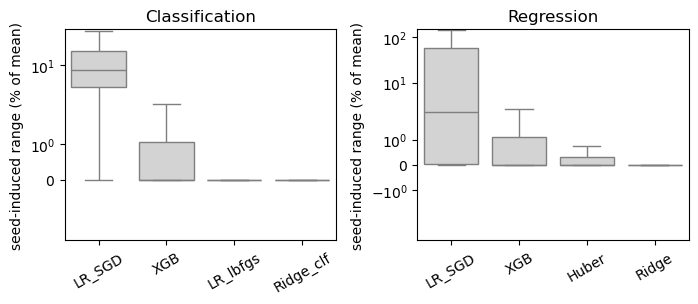

In [17]:
# --- save Notebook-1 outputs to supplementary/ ---
import matplotlib.pyplot as plt, seaborn as sns
#import utils; utils.frontiers_style()

# (these summary frames are what your cell already printed — rebuild/save them)
sc = sr_clf.groupby('algorithm')['seed_range_pct'].agg(
        median='median', p95=lambda x: np.percentile(x,95), max='max').round(2).sort_values('p95', ascending=False)
sg = sr_reg.groupby('algorithm')['seed_range_pct'].agg(
        median='median', p95=lambda x: np.percentile(x,95), max='max').round(2).sort_values('p95', ascending=False)
sc.to_csv(SUPP / "S6_seed_sensitivity_solvers_clf.csv")
sg.to_csv(SUPP / "S6_seed_sensitivity_solvers_reg.csv")

# failure-rate tables 
try:
    fr_clf.to_frame('failure_pct').to_csv(SUPP / "S6_failure_rates_clf.csv")
    fr_reg.to_frame('failure_pct').to_csv(SUPP / "S6_failure_rates_reg.csv")
except NameError:
    print("(failure-rate Series not named fr_clf/fr_reg — save them manually if needed)")

# --- supplementary figure: SGD vs deterministic seed-range collapse ---
fig, axes = plt.subplots(1, 2, figsize=(180/25.4, 80/25.4))
for ax, sr, title in [(axes[0], sr_clf, 'Classification'), (axes[1], sr_reg, 'Regression')]:
    order = sr.groupby('algorithm')['seed_range_pct'].apply(lambda x: np.percentile(x,95)).sort_values(ascending=False).index.tolist()
    sns.boxplot(data=sr, x='algorithm', y='seed_range_pct', order=order, ax=ax, showfliers=False, color='lightgray')
    ax.set_yscale('symlog'); ax.set_title(title)
    ax.set_ylabel('seed-induced range (% of mean)'); ax.set_xlabel('')
    ax.tick_params(axis='x', labelrotation=30)
plt.tight_layout()
fig.savefig(SUPP / "S6_solver_seed_sensitivity.pdf", dpi=300, bbox_inches='tight')
fig.savefig(SUPP / "S6_solver_seed_sensitivity.png", dpi=300, bbox_inches='tight')
print("saved S6 tables + figure")